In [1]:
!uv pip install transformers accelerate torch sentencepiece huggingface_hub pyyaml --upgrade

Using Python 3.14.6 environment at: c:\Users\user\Downloads\AI-Training\.venv
Resolved 38 packages in 478ms
Checked 38 packages in 6ms


In [ ]:
# Task 2: Prompt Engineering

import os
import warnings
import logging
import torch

from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Suppress Warnings

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

os.environ["TRANSFORMERS_VERBOSITY"] = "error"

# Load Environment Variables
load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")

# Model Name
model_name = "HuggingFaceTB/SmolLM2-360M-Instruct"

# Load Tokenizer
print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    token=HF_TOKEN
)

# Load Model
print("Loading model...")

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    token=HF_TOKEN,
    dtype=torch.float32
)

print("Model loaded successfully!")

# Create Hugging Face Pipeline

chatbot = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer
)

# System Prompt
system_prompt =  """
You are MediAssist AI, a professional healthcare assistant.

Context:
The user wants to learn about diabetes for educational purposes only.

Constraints:
- Provide only general medical information.
- Do not diagnose diseases.
- Do not prescribe medicines.
- Use simple language.
- Keep the response concise.

Output Format (Markdown):

# Disease Overview
# Symptoms
# Risk Factors
# Prevention
# When to Consult a Doctor
# Disclaimer

"""

# Welcome Message
print("=" * 60)
print("        MediAssist AI Healthcare Chatbot")
print("=" * 60)
print("Type 'exit' to quit.\n")

# Interactive Chat
while True:

    question = input("User: ").strip()

    if question.lower() == "exit":
        print("\nAssistant: Thank you for using MediAssist AI. Stay healthy!")
        break

    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": question
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    response = chatbot(
        prompt,
        max_new_tokens=250,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_text = response[0]["generated_text"]

    answer = generated_text[len(prompt):].strip()

    print(f"User: {question}\n")
    print("Assistant:\n")
    print(answer)
print("=" * 60)

c:\Users\user\Downloads\AI-Training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer...
Loading model...


Loading weights: 100%|██████████| 290/290 [00:03<00:00, 85.79it/s] 


Model loaded successfully!
        MediAssist AI Healthcare Chatbot
Type 'exit' to quit.

User: Tell me about diabetes

Assistant:

Diabetes is a chronic condition where your body has trouble regulating blood sugar levels. There are two main types of diabetes: Type 1 and Type 2.

**Type 1 Diabetes:**
In this type, the pancreas does not produce enough insulin, which is a hormone that regulates blood sugar levels. People with Type 1 diabetes need to take insulin every day to manage their condition. They may also have other health issues like vision problems or kidney damage.

**Type 2 Diabetes:**
This type occurs when your body becomes less responsive to insulin, making it harder for glucose to enter cells. Many people develop Type 2 diabetes later in life, but it can be managed through diet, exercise, and medication. Some common symptoms include increased thirst and hunger, frequent urination, fatigue, and blurred vision.

**Risk Factors:**
Diabetes increases the risk of heart disease, 

KeyboardInterrupt: Interrupted by user

# Improved Prompt

prompt = """
You are MediAssist AI, a professional healthcare assistant.

Context:
The user wants to learn about diabetes for educational purposes only.

Constraints:
- Provide only general medical information.
- Do not diagnose diseases.
- Do not prescribe medicines.
- Use simple language.
- Keep the response concise.

Output Format (Markdown):

# Disease Overview
# Symptoms
# Risk Factors
# Prevention
# When to Consult a Doctor
# Disclaimer

"""

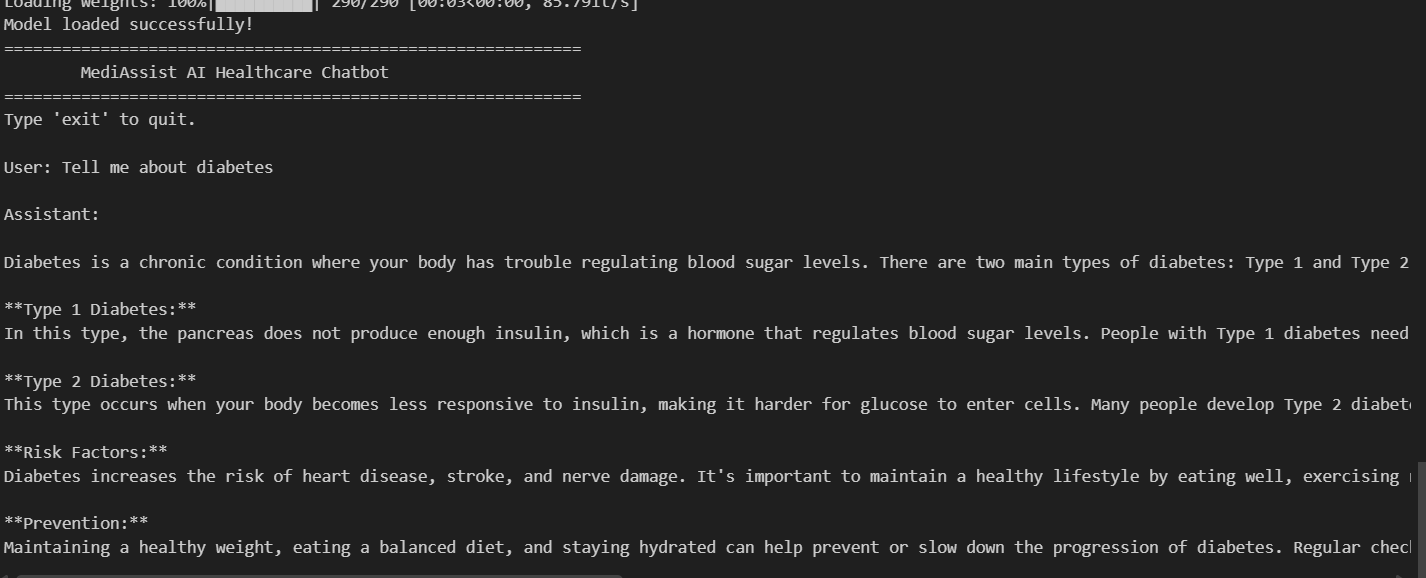 

# Short Report

## Model Selection
- Selected **HuggingFaceTB/SmolLM2-360M-Instruct** as the chatbot model.
- Chosen because it is an instruction-tuned model available on Hugging Face.
- Lightweight and suitable for CPU-based systems with limited memory.
- Compatible with **AutoTokenizer**, **AutoModelForCausalLM**, and the **Transformers pipeline**.
- Provides reliable responses for educational healthcare queries.

---

## Prompt Engineering Techniques Used
- **Role Prompting:** Assigned the model the role of *MediAssist AI*, a professional healthcare assistant.
- **Context Prompting:** Specified that the user is requesting educational healthcare information.
- **Constraint Prompting:** Restricted the model from diagnosing diseases or prescribing medicines.
- **Output Formatting:** Structured responses using Markdown headings and bullet points.
- **Safety Prompting:** Included a disclaimer encouraging consultation with a healthcare professional.

---

## Challenges Faced
- Larger Hugging Face models required more memory than the available hardware.
- CPU-only execution increased response generation time.
- Smaller models occasionally ignored formatting instructions.
- Transformers produced warning messages and deprecated parameter notifications.
- Multiple prompt refinements were needed to improve response consistency.

---

## Improvements Made After Prompt Refinement
- Refined the system prompt with clearer instructions.
- Added role, context, constraints, and output formatting to improve response quality.
- Enforced structured, point-wise Markdown responses.
- Added medical safety guidelines and disclaimers.
- Updated deprecated parameters and removed unnecessary warnings for cleaner execution.